<a href="https://colab.research.google.com/github/walid885/AstroVelocity/blob/main/AstroVelocity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
"""
the first interaction with the dataset, in order
to get an idea about the quality of the data set , as well ,
how well is it established !
"""
# Assuming your dataset is in a CSV format
# Replace 'your_dataset.csv' with the actual path to your dataset
df = pd.read_csv('/content/SDSS_DR18.csv')

# Display the first 10 rows
print(df.head(10))

# Basic dataset information
print("\nDataset Info:")
print(f"Shape: {df.shape}")
print(f"Number of features: {len(df.columns)}")
print(f"Column names: {df.columns.tolist()}")

# Data types of columns
print("\nData Types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Check for unique values in each column (for categorical features)
print("\nUnique Values in Each Column:")
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}: {df[col].nunique()} unique values")

Is GPU available: True
GPU Info: b'Tesla T4'
Original dataset shape: (100000, 43)
Using features: ['u_g', 'g_r', 'r_i', 'i_z', 'expAB_r', 'psfMag_r', 'redshift']
Training GPU-accelerated Random Forest classifier...


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)


Accuracy: 0.9971


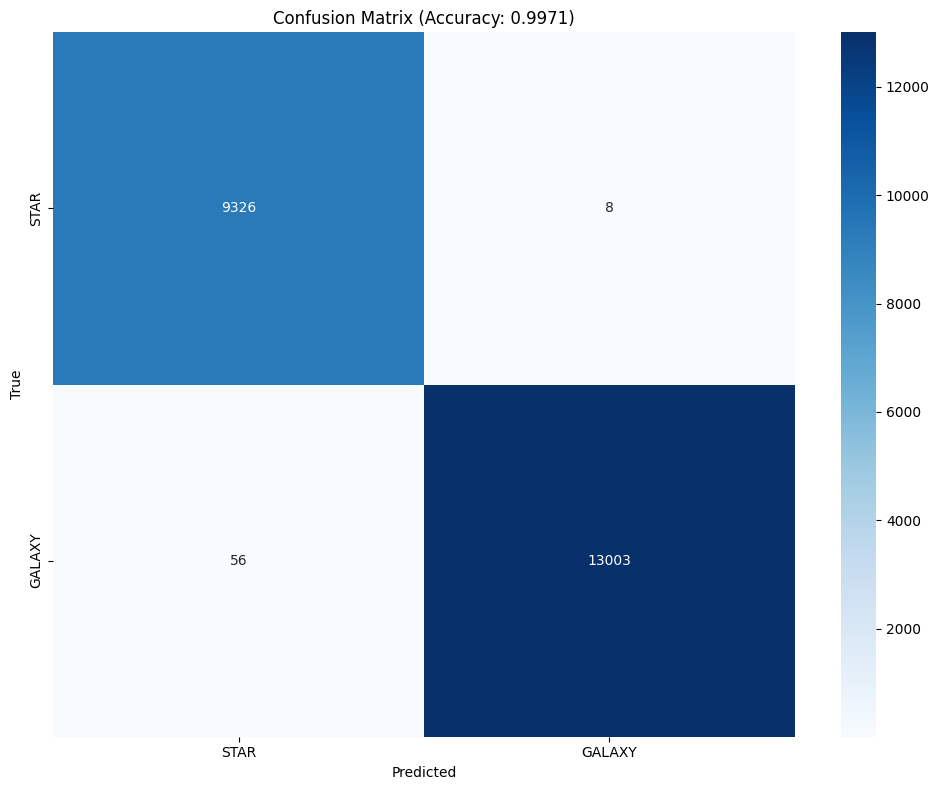

Performance across redshift ranges:
 Redshift 0-0.1: 0.9954 (samples: 13738)
 Redshift 0.1-0.3: 1.0000 (samples: 3364)
 Redshift 0.3-0.5: 1.0000 (samples: 9)
 Redshift 0.5-1.0: 1.0000 (samples: 13)
 Redshift 1.0+: 1.0000 (samples: 3)


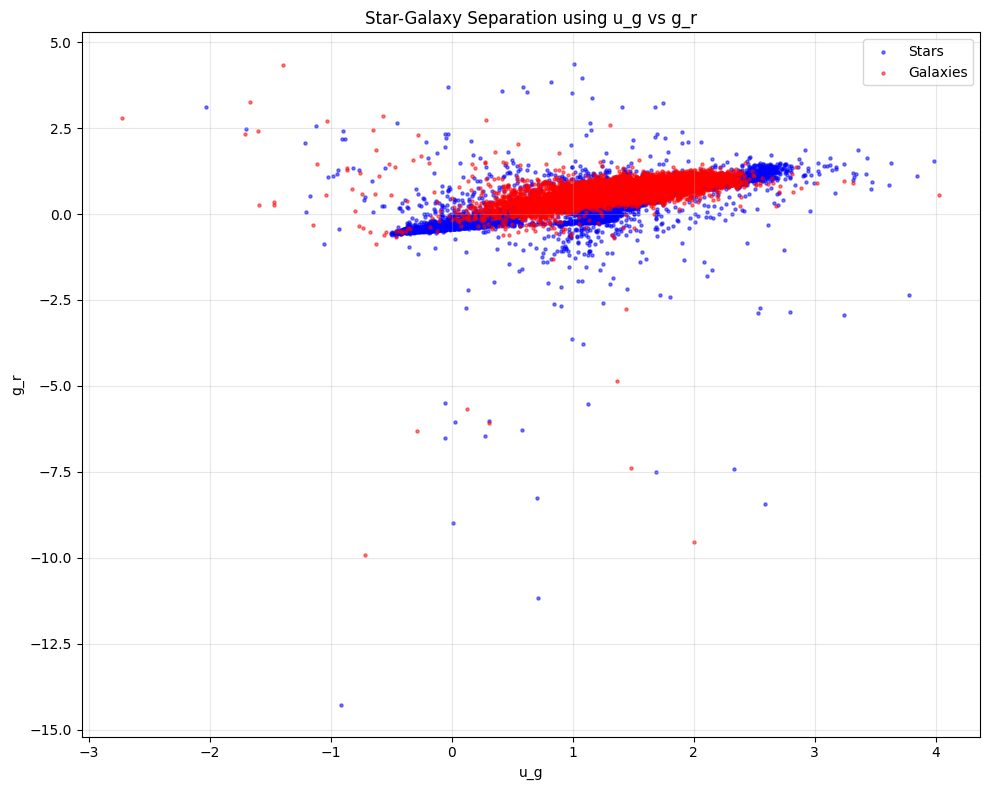


Classification demo is complete!


In [12]:
# Install required packages first
!pip install cudf-cu12 cuml-cu12 cupy-cuda12x

import pandas as pd
import numpy as np
import cudf
import cupy as cp
from cuml.preprocessing import StandardScaler
from cuml.model_selection import train_test_split
from cuml.ensemble import RandomForestClassifier
from cuml.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Check if GPU is available
print("Is GPU available:", cp.is_available())
if cp.is_available():
    print("GPU Info:", cp.cuda.runtime.getDeviceProperties(0)['name'])

# Load dataset
df = pd.read_csv('/content/SDSS_DR18.csv')

# Basic preprocessing
print("Original dataset shape:", df.shape)

# Create a binary target: Galaxy vs Star (remove QSO if present)
df = df[df['class'].isin(['GALAXY', 'STAR'])]
df['target'] = (df['class'] == 'GALAXY').astype(int) # 1 for GALAXY, 0 for STAR

# Create color indices directly in pandas before transferring to GPU
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

# Transfer to GPU with cuDF
gdf = cudf.DataFrame.from_pandas(df)

# Define base features (always available)
base_features = ['u_g', 'g_r', 'r_i', 'i_z']

# Add morphology features if available
morph_features = []
for band in ['r']:
    if f'expAB_{band}' in gdf.columns:
        morph_features.append(f'expAB_{band}')

# Add magnitude features if available
mag_features = []
if 'psfMag_r' in gdf.columns:
    mag_features.append('psfMag_r')

# Add redshift if available
redshift_feature = []
if 'redshift' in gdf.columns:
    redshift_feature = ['redshift']

# Combine all features
features = base_features + morph_features + mag_features + redshift_feature
print(f"Using features: {features}")

# Select only the needed features and handle missing values
X = gdf[features].fillna(gdf[features].mean())
y = gdf['target']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Random Forest classifier on GPU
print("Training GPU-accelerated Random Forest classifier...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    max_features='sqrt',
    n_bins=128,
    random_state=42
)
rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Convert predictions to CPU for visualization and analysis
y_test_cpu = y_test.to_pandas().values
y_pred_cpu = y_pred.to_pandas().values

# Calculate confusion matrix
cm = confusion_matrix(y_test_cpu, y_pred_cpu)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['STAR', 'GALAXY'],
           yticklabels=['STAR', 'GALAXY'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.4f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Function to assess model performance on different redshift ranges
def evaluate_by_redshift(df, y_true, y_pred):
    if 'redshift' not in df.columns:
        print("Redshift column not available for evaluation")
        return

    df_results = df.copy()
    df_results['y_true'] = y_true
    df_results['y_pred'] = y_pred

    # Define redshift bins
    redshift_bins = [0, 0.1, 0.3, 0.5, 1.0, float('inf')]
    redshift_labels = ['0-0.1', '0.1-0.3', '0.3-0.5', '0.5-1.0', '1.0+']

    print("Performance across redshift ranges:")
    for i in range(len(redshift_bins) - 1):
        bin_range = f"{redshift_labels[i]}"
        bin_data = df_results[(df_results['redshift'] >= redshift_bins[i]) &
                             (df_results['redshift'] < redshift_bins[i+1])]

        if len(bin_data) > 0:
            bin_acc = (bin_data['y_true'] == bin_data['y_pred']).mean()
            print(f" Redshift {bin_range}: {bin_acc:.4f} (samples: {len(bin_data)})")

# Evaluate performance by redshift if available
df_cpu = df.loc[X_test.index.to_numpy()]
evaluate_by_redshift(df_cpu, y_test_cpu, y_pred_cpu)

# Create color-color diagram
def visualize_star_galaxy_separation(df, features=['u_g', 'g_r'], class_col='class'):
    plt.figure(figsize=(10, 8))

    # Plot stars
    stars = df[df[class_col] == 'STAR']
    plt.scatter(stars[features[0]], stars[features[1]],
               c='blue', alpha=0.5, s=5, label='Stars')

    # Plot galaxies
    galaxies = df[df[class_col] == 'GALAXY']
    plt.scatter(galaxies[features[0]], galaxies[features[1]],
               c='red', alpha=0.5, s=5, label='Galaxies')

    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.title(f'Star-Galaxy Separation using {features[0]} vs {features[1]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create color-color diagram
visualize_star_galaxy_separation(df)

print("\nClassification demo is complete!")

In [ ]:
!pip install cudf-cu12 cuml-cu12 cupy-cuda12x
